In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/clean_data

/content/drive/MyDrive/clean_data


In [3]:
%ls

Competition.csv   Ends.csv        logs/         runner.py         Teams.csv
Competitors.csv   full_array.csv  Main.Rmd      Stones.csv        Untitled.Rmd
CurlingCNN.ipynb  Games.csv       __pycache__/  stones_final.csv


In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset

In [5]:
nndata = pd.read_csv('stones_final.csv')

/tmp/ipython-input-1751436126.py:1: DtypeWarning: Columns (108) have mixed types. Specify dtype option on import or set low_memory=False.
  nndata = pd.read_csv('stones_final.csv')


In [6]:
cols = [f"stone_{i}_{axis}" for i in range(1, 13) for axis in ["x", "y"]]
cols.append('Team1_Hammer')
cols.append('EndID')
cols.append('ShotID')
# Subset the DataFrame
nninput = nndata[cols]

In [7]:
resets = nninput["EndID"] < nninput["EndID"].shift()
block_id = resets.cumsum()
nninput["EndID_full"] = nninput["EndID"] + block_id.max() * block_id / block_id.max()
nninput["EndID_full"] = nninput["EndID"] + block_id.max() * 0
nninput["EndID_full"] = nninput["EndID"] + block_id

/tmp/ipython-input-3836331692.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nninput["EndID_full"] = nninput["EndID"] + block_id.max() * block_id / block_id.max()
/tmp/ipython-input-3836331692.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nninput["EndID_full"] = nninput["EndID"] + block_id.max() * 0
/tmp/ipython-input-3836331692.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

In [8]:
for col in nninput.columns[:-4]:
    nninput[col] = pd.to_numeric(nninput[col], errors='coerce').astype('Int64')

/tmp/ipython-input-4278348394.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nninput[col] = pd.to_numeric(nninput[col], errors='coerce').astype('Int64')


In [9]:
#filter to shotId > 5
nninput = nninput[nninput['ShotID'] > 5]

In [10]:
nninput

,stone_1_x,stone_1_y,stone_2_x,stone_2_y,stone_3_x,stone_3_y,stone_4_x,stone_4_y,stone_5_x,stone_5_y,...,stone_10_x,stone_10_y,stone_11_x,stone_11_y,stone_12_x,stone_12_y,Team1_Hammer,EndID,ShotID,EndID_full
5,963,1657,<NA>,<NA>,671,713,600,798,<NA>,<NA>,...,590,1164,<NA>,<NA>,<NA>,<NA>,False,1,6,1
6,963,1657,<NA>,<NA>,671,684,600,798,830,648,...,590,1164,<NA>,<NA>,<NA>,<NA>,False,1,7,1
7,963,1657,<NA>,<NA>,671,684,600,798,830,648,...,590,1164,671,850,<NA>,<NA>,False,1,8,1
8,963,1657,<NA>,<NA>,671,684,600,798,830,648,...,590,1164,671,850,<NA>,<NA>,False,1,9,1
9,963,1657,<NA>,<NA>,671,684,600,798,830,648,...,590,1164,671,850,1031,496,False,1,10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26365,<NA>,<NA>,<NA>,<NA>,429,179,<NA>,<NA>,<NA>,<NA>,...,500,567,<NA>,<NA>,<NA>,<NA>,False,7,6,350
26366,<NA>,<NA>,<NA>,<NA>,429,179,<NA>,<NA>,760,1152,...,500,567,<NA>,<NA>,<NA>,<NA>,False,7,7,350
26367,<NA>,<NA>,<NA>,<NA>,429,179,<NA>,<NA>,<NA>,<NA>,...,500,567,272,797,<NA>,<NA>,False,7,8,350
26368,<NA>,<NA>,<NA>,<NA>,429,179,<NA>,<NA>,<NA>,<NA>,...,500,567,272,797,<NA>,<NA>,False,7,9,350


In [11]:
np.arange(len(nninput))

array([    0,     1,     2, ..., 13182, 13183, 13184])

In [12]:
sheet_id = np.arange(len(nninput))[:10000]
sheets = {}
for id in sheet_id:
    sheets[f"sheet_{id}"] = np.zeros((2, 150, 300), dtype=np.int8)

In [13]:
sheets["sheet_0"]

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=int8)

In [14]:
import torch
import numpy as np
import pandas as pd


limit = 10000

all_x_cols = [col for col in nninput.columns if '_x' in col]
all_y_cols = [col for col in nninput.columns if '_y' in col]

SRC_MAX_X = nninput[all_x_cols].max().max()
SRC_MAX_Y = nninput[all_y_cols].max().max()

print(f"Max X: {SRC_MAX_X}, Max Y: {SRC_MAX_Y}")

TGT_H = 150
TGT_W = 300


valid_indices = nninput.index[:limit]


y_raw = nndata.loc[valid_indices, 'Result_Team1']
labels = (y_raw > 0).astype(int).values
labels = torch.tensor(labels, dtype=torch.float32)

sheets_list = []

for i, idx in enumerate(valid_indices):

    sheet = np.zeros((3, TGT_H, TGT_W), dtype=np.float32)
    row = nninput.loc[idx]


    team1_has_hammer = row['Team1_Hammer']

    if not team1_has_hammer:
        ch_team1, ch_team2 = 0, 1
    else:
        ch_team1, ch_team2 = 1, 0


    if team1_has_hammer:
        sheet[2, :, :] = 1.0


    for s in range(1, 13):
        x = row[f"stone_{s}_x"]
        y = row[f"stone_{s}_y"]

        if pd.isna(x) or pd.isna(y):
            continue


        px = int((x / SRC_MAX_X) * TGT_H)
        py = int((y / SRC_MAX_Y) * TGT_W)


        px = max(0, min(px, TGT_H - 1))
        py = max(0, min(py, TGT_W - 1))


        ch = ch_team1 if s <= 6 else ch_team2


        x_start = max(0, px - 1)
        x_end = min(TGT_H, px + 2)
        y_start = max(0, py - 1)
        y_end = min(TGT_W, py + 2)

        sheet[ch, x_start:x_end, y_start:y_end] = 1.0


    sheets_list.append(sheet)

inputs = torch.tensor(np.stack(sheets_list), dtype=torch.float32)

print(f"New Inputs Shape: {inputs.shape}")


print(f"Labels Shape: {labels.shape}")


Max X: 1457, Max Y: 2954
New Inputs Shape: torch.Size([10000, 3, 150, 300])
Labels Shape: torch.Size([10000])


In [15]:
np.max(sheets['sheet_10'])

np.int8(0)

In [16]:
labels.shape

torch.Size([10000])

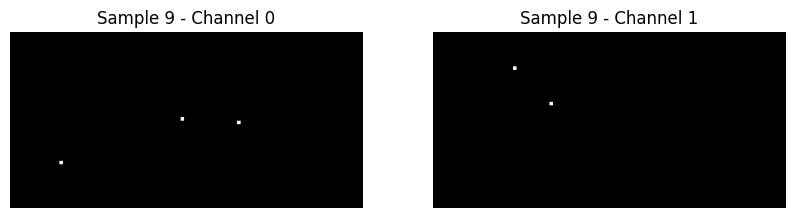

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline
def show_sample(batch, index=0):
    img = batch[index]      # [2, H, W]

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    for c in range(2):
        axs[c].imshow(img[c].cpu().numpy(), cmap='gray')
        axs[c].set_title(f"Sample {index} - Channel {c}")
        axs[c].axis('off')

    plt.show()

show_sample(inputs, 9)

In [18]:
x_train  = inputs[:9900]
x_test = inputs[9900:]
y_train = labels[:9900]
y_test = labels[9900:]

In [19]:
x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)

/tmp/ipython-input-4238191440.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train = torch.tensor(x_train, dtype=torch.float32)
/tmp/ipython-input-4238191440.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test = torch.tensor(x_test, dtype=torch.float32)


In [20]:
x_train.shape

torch.Size([9900, 3, 150, 300])

In [21]:
!pip install catalyst

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 5.3 MB/s eta 0:00:00
Requested catalyst from https://files.pythonhosted.org/packages/05/09/36a4acd1c3112f2e2da74f4340778100a205ecb59166be00dc6287f3364f/catalyst-22.4-py2.py3-none-any.whl has invalid metadata: Expected matching RIGHT_PARENTHESIS for LEFT_PARENTHESIS, after version specifier
    scikit-image (<0.19.0>=0.16.1) ; extra == 'all'
                 ~~~~~~~~^
Please use pip<24.1 if you need to use this version.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 5.6 MB/s eta 0:00:00
Requested catalyst from https://files.pythonhosted.org/packages/28/4f/380899b95b45f02182e7163b4e9be4749724c898886d70009168bfd07409/catalyst-22.2.1-py2.py3-none-any.whl has invalid metadata: Expected matching RIGHT_PARENTHESIS for LEFT_PARENTHESIS, after version specifier
    scikit-image (<0.19.0>=0.16.1) ; extra == 'all'
                 ~~~~~~~~^
Please use pip<24.1 if you need to use this version.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [22]:
from sklearn.model_selection import KFold
import collections
import collections.abc
collections.MutableMapping = collections.abc.MutableMapping
from catalyst import dl, metrics
from catalyst.utils import set_global_seed
from catalyst.callbacks.checkpoint import CheckpointCallback

from catalyst import dl, metrics, utils

class CustomRunner(dl.Runner):
    def __init__(self):
        super().__init__()
        self.train_losses = []
        self.valid_losses = []

    def on_loader_start(self, runner):
        super().on_loader_start(runner)
        self.meters = {
            key: metrics.AdditiveValueMetric(compute_on_call=False)
            for key in ["loss"]
        }

    def handle_batch(self, batch):
        x, y = batch
        #x = x.view(len(x), -1)
        y_pred = self.model(x)
        loss = self.criterion(y_pred, y)
        self.batch_metrics.update({"loss": loss})

        for key in ["loss"]:
            self.meters[key].update(self.batch_metrics[key].item(), self.batch_size)

        if self.is_train_loader:
            loss.backward()
            self.optimizer.step()
            self.optimizer.zero_grad()

    def on_loader_end(self, runner):
        for key in ["loss"]:
            self.loader_metrics[key] = self.meters[key].compute()[0]
        if self.loader_key == "train":
            self.train_losses.append(self.loader_metrics["loss"])
        elif self.loader_key == "valid":
            self.valid_losses.append(self.loader_metrics["loss"])
        super().on_loader_end(runner)

In [23]:
class NeuralNetCNN(nn.Module):
    def __init__(self, in_channels=2, num_outputs=1):
        super(NeuralNetCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=5, stride=2, padding=2)
        self.bn1 = nn.GroupNorm(4, 16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.GroupNorm(8, 32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.GroupNorm(8, 32)

        self.global_pool = nn.AdaptiveMaxPool2d((1, 1))

        self.fc1 = nn.Linear(64 + 1, 32)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, num_outputs)

    def forward(self, x):

        visual_x = x[:, 0:2, :, :]
        context_x = x[:, 2, :, :]

        out = F.leaky_relu(self.bn1(self.conv1(visual_x)), 0.1)
        out = F.leaky_relu(self.bn2(self.conv2(out)), 0.1)
        out = F.leaky_relu(self.bn3(self.conv3(out)), 0.1)

        out = self.global_pool(out)
        visual_features = out.view(out.size(0), -1)


        hammer_feature = context_x.mean(dim=(1, 2)).unsqueeze(1)


        combined = torch.cat((visual_features, hammer_feature), dim=1)


        out = F.relu(self.fc1(combined))
        out = self.dropout(out)
        out = self.fc2(out)

        return out

In [24]:
print(y_train.min(), y_train.max(), y_train.dtype)


tensor(0.) tensor(1.) torch.float32


In [ ]:
import torch.nn.functional as F
kf = KFold(n_splits=5, shuffle=False)
fold_metrics = []


dataset = TensorDataset(
    torch.tensor(x_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
)

set_global_seed(123)

for fold, (train_idx, val_idx) in enumerate(kf.split(x_train)):
    print(f"Fold {fold+1}")


    train_dataset = Subset(dataset, train_idx)
    val_dataset = Subset(dataset, val_idx)


    train_loader = DataLoader(train_dataset, batch_size=64, num_workers=0, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=64, num_workers=0, shuffle=False)


    model = NeuralNetCNN(in_channels=2, num_outputs=1)
    model = model.to("cuda")                     # move model to GPU

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.BCEWithLogitsLoss()

    runner = CustomRunner()

    runner.train(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        loaders={"train": train_loader, "valid": val_loader},
        num_epochs=50,
        logdir=f"./logs/fold_{fold}",
        valid_loader="valid",
        valid_metric="loss",
        minimize_valid_metric=True,
        seed=123
    )

    fold_metrics.append(runner.loader_metrics["loss"])

/tmp/ipython-input-2670552930.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(x_train, dtype=torch.float32),


Fold 1


/usr/local/lib/python3.12/dist-packages/catalyst/core/runner.py:716: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  k: runner.engine.sync_tensor(torch.tensor(v, device=runner.device), "mean")


train (1/50) loss: 0.7303613004058299
valid (1/50) loss: 0.6929873141375456
* Epoch (1/50) 
train (2/50) loss: 0.6924051296831379
valid (2/50) loss: 0.6918968424652562
* Epoch (2/50) 
train (3/50) loss: 0.6922498741535223
valid (3/50) loss: 0.6925980596831349
* Epoch (3/50) 
train (4/50) loss: 0.6911172252712825
valid (4/50) loss: 0.6949077913255401
* Epoch (4/50) 
train (5/50) loss: 0.6921161503502813
valid (5/50) loss: 0.6919334187652126
* Epoch (5/50) 
train (6/50) loss: 0.691577588307737
valid (6/50) loss: 0.6919404094869441
* Epoch (6/50) 
train (7/50) loss: 0.6903304497400918
valid (7/50) loss: 0.6919813280153757
* Epoch (7/50) 
train (8/50) loss: 0.6905933360860802
valid (8/50) loss: 0.6920393401926215
* Epoch (8/50) 
train (9/50) loss: 0.6906503848355223
valid (9/50) loss: 0.6923716850955076
* Epoch (9/50) 
train (10/50) loss: 0.6883259927383576
valid (10/50) loss: 0.6919317937860586
* Epoch (10/50) 
train (11/50) loss: 0.6895533346166511
valid (11/50) loss: 0.6925518270694849


In [ ]:
model.eval()
x_test = x_test.to(device)
with torch.no_grad():
    outputs = model(x_test)       # logits
    probs = torch.sigmoid(outputs)  # probabilities
    preds = (probs >= 0.5).long()

In [ ]:
y_test

tensor([0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 1., 1., 1., 1., 0., 0., 0., 0., 0.])

In [ ]:
preds

tensor([[1],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [0],
        [0],
        [0],
        [1],
        [0],
        [1],
        [1],
        [0],
        [0],
        [0],
        [0],
        [1],
        [0],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [0],
        [0],
        [0],
        [1],
        [0],
        [0],
        [1],
        [1],
        [1],
        [0],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [0],
        [1],
        [1],
        [0],
        [0],
        [0],
        [1],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [1],
        [1],
        [1],
        [0],
        [1],
        [1],
        [1],

In [ ]:
y_test = y_test.to(device)


In [ ]:
correct = (preds.squeeze() == y_test.squeeze()).sum().item()

# Compute accuracy
accuracy = correct / y_test.size(0)

print(f"Test Accuracy: {accuracy*100:.2f}%")

Test Accuracy: 52.00%
